# Image classification — a runnable, measured workflow

Image classification assigns a whole image to one of $K$ labels. The naive attack — feed raw pixels to a classifier and train from zero — needs *millions* of labeled images to generalize, which you rarely have. The move that dominates applied vision is **transfer learning**: reuse the visual features a big model already learned on a huge dataset (ImageNet), and train only a small new head on your task. This notebook runs that workflow on **real** CIFAR-10 images and measures every claim.

It uses the **exact same functions** as the companion page and its figures (imported from `image_classification.py`), so the numbers here are the numbers there. We build the loss and the metrics from scratch (checked against `torch` and `scikit-learn`), then: load a balanced real subset, freeze a pretrained **ResNet-18** backbone, train a **linear probe** on its features (transfer), compare against a **from-scratch CNN** at the same budget (transfer wins by a measured margin), ablate **augmentation** (the overfitting gap shrinks), and evaluate honestly with a confusion matrix, per-class accuracy, and a prediction grid that shows real mistakes.

> Companion page: **Image Classification**. Run top-to-bottom (Kernel → Restart & Run All). The reported training is **CPU-pinned and seeded** for a reproducible trace (a few minutes end-to-end); the heavy work happens once in Step 6.

## Step 0 — Setup: import the real module and print versions

We import the pipeline functions from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions + the accelerator we detected (we still train on CPU on purpose — GPU kernels are nondeterministic and every number here must be bit-reproducible).

In [1]:
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

import image_classification as ic

print(f'torch {torch.__version__} | torchvision {torchvision.__version__} | numpy {np.__version__}')
print(f'accelerator available: {ic.detect_accelerator()}  (reported metrics are CPU-pinned, seed={ic.SEED})')

torch 2.12.0 | torchvision 0.27.0 | numpy 2.4.6
accelerator available: mps  (reported metrics are CPU-pinned, seed=0)


## Step 1 — The classification loss: softmax + cross-entropy, from scratch

A classifier outputs one **logit** per class. **Softmax** turns logits into a probability distribution, and **cross-entropy** scores how much probability the model put on the *true* class:

$$\mathrm{softmax}(z)_i = \frac{e^{z_i - m}}{\sum_j e^{z_j - m}},\quad m=\max_j z_j; \qquad \mathcal{L} = -\frac{1}{N}\sum_i \log \mathrm{softmax}(z_i)[y_i].$$

The $-m$ shift is the one numerical-stability trick that matters: it stops $e^{z}$ from overflowing without changing the result. We implement both by hand and check them against `torch` to ~1e-6. (Full derivation: Foundations 23 — Cross-Entropy.)

In [2]:
lc = ic.verify_softmax_cross_entropy()
print(f'cross-entropy  from scratch : {lc.ce_scratch:.6f}')
print(f'cross-entropy  torch        : {lc.ce_torch:.6f}')
print(f'max|softmax - torch softmax|: {lc.softmax_vs_torch:.1e}')
print(f'|CE - torch CE|             : {lc.ce_vs_torch:.1e}')
assert lc.ce_vs_torch < 1e-6
print('OK: our softmax + cross-entropy match torch')

cross-entropy  from scratch : 4.818285
cross-entropy  torch        : 4.818285
max|softmax - torch softmax|: 1.1e-16
|CE - torch CE|             : 8.9e-16
OK: our softmax + cross-entropy match torch


## Step 2 — Evaluation metrics from scratch, cross-checked against scikit-learn

How do we score a classifier? **Top-1 accuracy** = fraction whose single best guess is right. **Top-5 accuracy** = fraction whose true label is among the 5 best guesses (the standard ImageNet metric, since a single guess over 1000 classes is a harsh bar). The **confusion matrix** $C[t,p]$ counts true-class-$t$ images predicted as $p$ — its off-diagonal *is* the list of mistakes. We implement all of them in NumPy and cross-check against `sklearn.metrics` on a small synthetic example (they must match exactly).

In [3]:
rng = np.random.default_rng(0)
toy_logits = rng.standard_normal((20, 6))
toy_y = rng.integers(0, 6, size=20)
print(f'top-1 (scratch): {ic.top1_accuracy(toy_logits, toy_y):.3f}')
print(f'top-5 (scratch): {ic.topk_accuracy(toy_logits, toy_y, k=5):.3f}')
cm = ic.confusion_matrix_from_scratch(toy_logits.argmax(1), toy_y, 6)
print('confusion matrix (rows=true, cols=pred):\n', cm)
check = ic.verify_metrics(toy_logits, toy_y, 6)
print(f'\nvs sklearn: |top1|={check.top1_vs_sklearn:.0e}  |top5|={check.top5_vs_sklearn:.0e}  '
      f'confusion==sklearn: {check.confusion_matches_sklearn}')
print('OK: our metrics ARE the standard metrics')

top-1 (scratch): 0.100
top-5 (scratch): 0.850
confusion matrix (rows=true, cols=pred):
 [[0 2 1 0 0 0]
 [2 1 1 1 0 2]
 [0 0 0 0 0 0]
 [0 0 2 1 0 0]
 [1 0 0 0 0 2]
 [1 1 1 1 0 0]]



vs sklearn: |top1|=0e+00  |top5|=0e+00  confusion==sklearn: True
OK: our metrics ARE the standard metrics


## Step 3 — Load real images: a balanced CIFAR-10 subset

CIFAR-10 is 60,000 real 32×32 RGB photos across 10 classes. We take a small **balanced** subset (equal per class) so runs are quick but honest — a realistic 'small labeled dataset', exactly the regime where transfer learning pays off. If the download is unavailable, the module falls back to a real bundled dataset (scikit-learn digits) so the notebook still runs on real images.

In [4]:
data = ic.try_load_cifar(train_per_class=300, test_per_class=100) or ic.load_digits_fallback()
print(f'dataset : {data.name}')
print(f'train   : {data.images_train.shape}   test: {data.images_test.shape}')
print(f'classes : {data.classes}')
print(f'transfer available (pretrained backbone reachable): {data.transfer_available}')

dataset : CIFAR-10
train   : (3000, 32, 32, 3)   test: (1000, 32, 32, 3)
classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
transfer available (pretrained backbone reachable): True


A quick look at the raw images — real, low-resolution, and varied in pose, lighting, and scale:

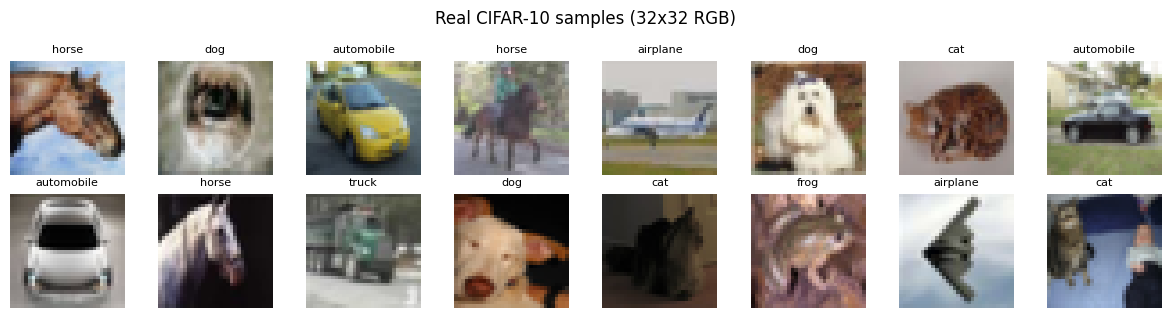

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, lbl in zip(axes.flat, data.images_train, data.labels_train):
    ax.imshow(img, cmap=None if data.is_rgb else 'gray')
    ax.set_title(data.classes[lbl], fontsize=8)
    ax.axis('off')
plt.suptitle('Real CIFAR-10 samples (32x32 RGB)')
plt.tight_layout()
plt.show()

## Step 4 — The input pipeline: resize + normalize for the backbone

A pretrained backbone expects the distribution it was trained on. So before the ImageNet ResNet-18 sees a CIFAR image we **resize** it to 224×224 and **normalize** each channel with ImageNet's mean/std. Matching the pretraining statistics is what lets the frozen features transfer.

Watch the per-channel mean *after* normalizing: it is **not** ~0, and that is the lesson, not a bug. Normalization subtracts the **ImageNet dataset** mean, so it centers the *ImageNet* distribution — not this single CIFAR image (a batch of one, from a different distribution). The residual gap from 0 you see below *is* the CIFAR≠ImageNet distribution mismatch the 'match the backbone's diet' section warns about; centering targets the dataset mean over many images, not any one image.

In [6]:
batch = ic._to_backbone_batch(data.images_train[:1])   # [1,3,224,224], ImageNet-normalized
print(f'pipeline: {data.images_train[:1].shape} uint8  ->  {tuple(batch.shape)} float (ImageNet-normalized)')
mean = batch.mean(dim=(0,2,3)).numpy().round(2)
print(f'per-channel mean of ONE CIFAR image after ImageNet-normalize: {mean}')
print('(NOT ~0 by design: ImageNet stats center the ImageNet dataset, not one CIFAR image ->')
print(' the residual gap from 0 is exactly the CIFAR vs ImageNet distribution mismatch.)')

pipeline: (1, 32, 32, 3) uint8  ->  (1, 3, 224, 224) float (ImageNet-normalized)
per-channel mean of ONE CIFAR image after ImageNet-normalize: [0.34 0.39 0.65]
(NOT ~0 by design: ImageNet stats center the ImageNet dataset, not one CIFAR image ->
 the residual gap from 0 is exactly the CIFAR vs ImageNet distribution mismatch.)


## Step 5 — The pretrained backbone as a frozen feature extractor

Transfer learning's core object: take an ImageNet-pretrained **ResNet-18**, throw away its 1000-way classification head, and keep the 512-dimensional feature it computes just before that head. Those 512 numbers are a *general visual summary* of the image — edges, textures, parts — that the backbone learned from 1.2M ImageNet photos. We **freeze** the backbone (never update it) and only read out features. Let's extract them for the first 12 images to see the shape (the full run in Step 6 extracts them for all).

In [7]:
if data.transfer_available:
    feats12 = ic.extract_features(data.images_train[:12])
    print(f'12 images -> features {tuple(feats12.shape)}  (512-D per image, from the FROZEN backbone)')
else:
    print('offline fallback: no pretrained backbone; Step 6 trains only the from-scratch CNN')

12 images -> features (12, 512)  (512-D per image, from the FROZEN backbone)


## Step 6 — Run the full measured pipeline (transfer + from-scratch + augmentation)

This one cell does the real training and is the notebook's heavy lifter (a few minutes, CPU-pinned and seeded). It extracts features for the whole subset, trains a **linear probe** on the frozen features (transfer), trains a **from-scratch CNN** at the same budget, trains the CNN again **with augmentation**, then evaluates the best model from scratch and cross-checks every metric against scikit-learn. It prints a full report; the following steps unpack and visualize it.

In [8]:
exp = ic.run_experiment(train_per_class=300, test_per_class=100, epochs=40)
print(f'dataset            : {exp.dataset_name}  ({exp.n_train} train / {exp.n_test} test)')
if exp.transfer_top1 is not None:
    print(f'transfer  top-1/5  : {exp.transfer_top1:.3f} / {exp.transfer_top5:.3f}  (head only, backbone frozen)')
    print(f'from-scratch top-1 : {exp.scratch_noaug.test_acc:.3f}  ({exp.scratch_noaug.n_params:,} params)')
    print(f'transfer advantage : {exp.transfer_delta*100:+.1f} points at the same budget')
print(f'aug gap: no-aug {exp.aug_gap_noaug*100:.1f} pts -> aug {exp.aug_gap_aug*100:.1f} pts')

dataset            : CIFAR-10  (3000 train / 1000 test)
transfer  top-1/5  : 0.800 / 0.993  (head only, backbone frozen)
from-scratch top-1 : 0.435  (94,986 params)
transfer advantage : +36.5 points at the same budget
aug gap: no-aug 12.8 pts -> aug 6.4 pts


## Step 7 — Transfer learning vs training from scratch (the measured win)

Same images, same labels, same budget — but the transfer model reuses features the backbone already learned, while the from-scratch CNN must learn everything from ~a few hundred images per class. The gap is the whole argument for transfer learning: **low-level visual features are reusable** (Yosinski et al. 2014), so you almost never train a vision model from zero.

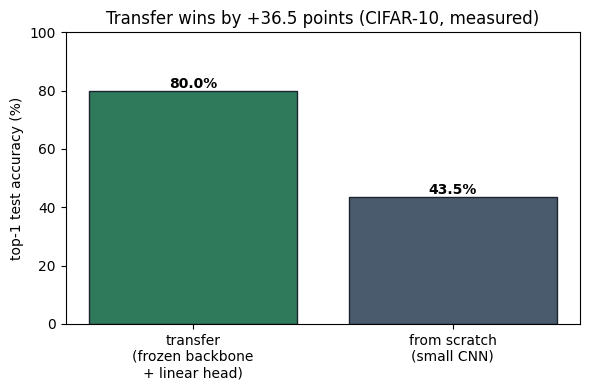

In [9]:
if exp.transfer_top1 is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    accs = [exp.transfer_top1*100, exp.scratch_noaug.test_acc*100]
    bars = ax.bar(['transfer\n(frozen backbone\n+ linear head)', 'from scratch\n(small CNN)'], accs,
                  color=['#2E7A5A', '#4A5B6E'], edgecolor='#1C2530')
    for b, v in zip(bars, accs):
        ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
    ax.set_ylabel('top-1 test accuracy (%)')
    ax.set_ylim(0, 100)
    ax.set_title(f'Transfer wins by {exp.transfer_delta*100:+.1f} points (CIFAR-10, measured)')
    plt.tight_layout()
    plt.show()
else:
    print('offline fallback: transfer comparison unavailable')

## Step 8 — Data augmentation: same label, new pixels

**Augmentation** creates new training views by applying *label-preserving* transforms — a random crop, a horizontal flip. A flipped cat is still a cat, so the label is unchanged, but the pixels differ every epoch, which discourages the network from memorizing exact pixel patterns. Here is one real image and several augmentations of it.

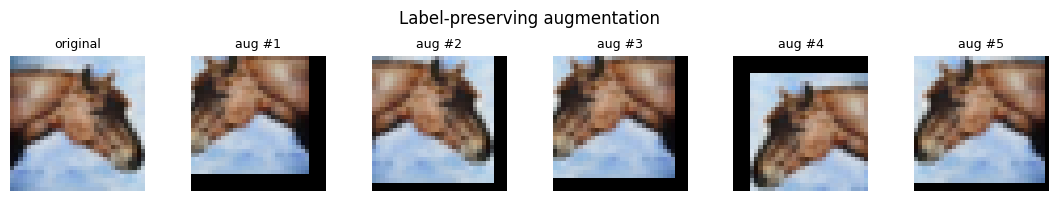

In [10]:
import torchvision.transforms.v2 as T
img = data.images_train[0]
x = torch.tensor(img if data.is_rgb else np.stack([img]*3, -1)).permute(2,0,1).float()/255.0
torch.manual_seed(0)
aug = T.Compose([T.RandomCrop(x.shape[-1], padding=4), T.RandomHorizontalFlip()])
fig, axes = plt.subplots(1, 6, figsize=(11, 2))
for ax in axes:
    ax.axis('off')
axes[0].imshow(x.permute(1,2,0).numpy())
axes[0].set_title('original', fontsize=9)
for i in range(1, 6):
    axes[i].imshow(aug(x).permute(1,2,0).numpy().clip(0,1))
    axes[i].set_title(f'aug #{i}', fontsize=9)
plt.suptitle('Label-preserving augmentation')
plt.tight_layout()
plt.show()

## Step 9 — Augmentation as a regularizer: the overfitting gap shrinks

Augmentation's payoff is measured as the **generalization gap** = train accuracy − test accuracy. A model that memorizes has a big gap (high train, lower test); a regularized model has a small one. With only a few hundred images per class the from-scratch CNN overfits — and augmentation roughly halves that gap. (At this tiny budget the test-accuracy gain is small and honest; the gap reduction is the reliable signature, and it grows into a test-accuracy win with more data / longer training.)

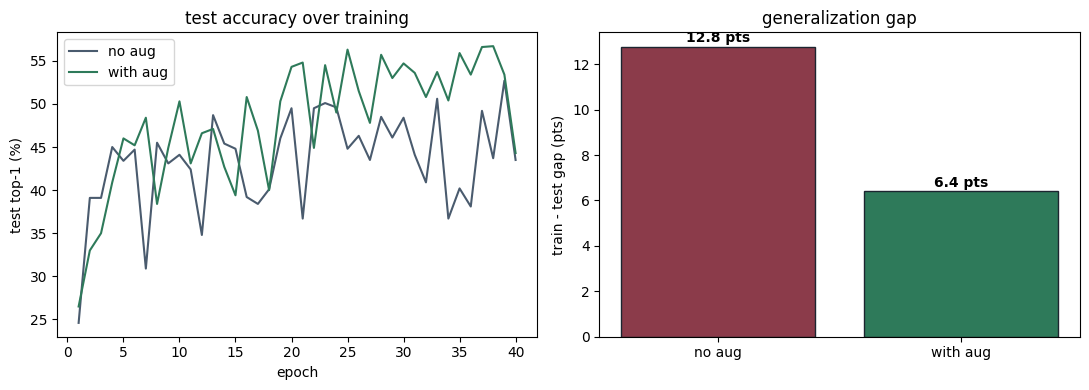

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
ep = np.arange(1, len(exp.scratch_noaug.val_curve)+1)
a1.plot(ep, np.array(exp.scratch_noaug.val_curve)*100, color='#4A5B6E', label='no aug')
a1.plot(ep, np.array(exp.scratch_aug.val_curve)*100, color='#2E7A5A', label='with aug')
a1.set_xlabel('epoch')
a1.set_ylabel('test top-1 (%)')
a1.legend()
a1.set_title('test accuracy over training')
gaps = [exp.aug_gap_noaug*100, exp.aug_gap_aug*100]
a2.bar(['no aug', 'with aug'], gaps, color=['#8B3B4A', '#2E7A5A'], edgecolor='#1C2530')
for i, g in enumerate(gaps):
    a2.text(i, g+0.2, f'{g:.1f} pts', ha='center', fontweight='bold')
a2.set_ylabel('train - test gap (pts)')
a2.set_title('generalization gap')
plt.tight_layout()
plt.show()

## Step 10 — Honest evaluation: the confusion matrix

A single accuracy number hides *where* a model fails. The confusion matrix shows it: a strong diagonal (correct) and telltale off-diagonal clusters (the systematic mistakes). On CIFAR-10 the classic confusions are between visually similar **animals** — cats and dogs, deer and horses — while rigid **vehicles** are cleanly separated.

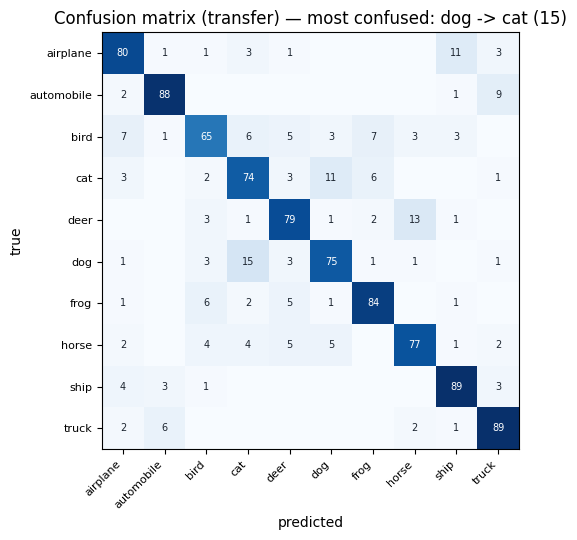

In [12]:
cm = exp.confusion
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(exp.classes)))
ax.set_yticks(range(len(exp.classes)))
ax.set_xticklabels(exp.classes, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(exp.classes, fontsize=8)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
for i in range(len(exp.classes)):
    for j in range(len(exp.classes)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                    color='white' if cm[i, j] > cm.max()/2 else '#1C2530')
cmn = cm.copy()
np.fill_diagonal(cmn, 0)
mi, mj = np.unravel_index(cmn.argmax(), cmn.shape)
ax.set_title(f'Confusion matrix (transfer) — most confused: {exp.classes[mi]} -> {exp.classes[mj]} ({cmn[mi,mj]})')
plt.tight_layout()
plt.show()

## Step 11 — Per-class accuracy: what the headline number hides

Break accuracy down by class and the averaging illusion disappears. Vehicles score far above the overall number; fine-grained animals score below it. This is exactly why accuracy alone is a poor summary on imbalanced or fine-grained problems — and why detection/segmentation reach for per-class metrics like mAP and IoU (Chapter 10).

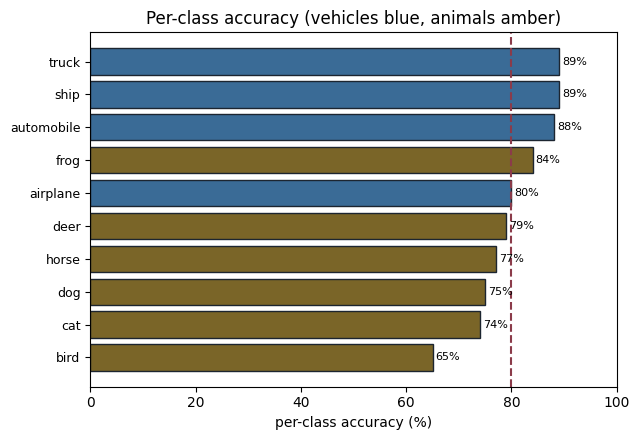

In [13]:
order = np.argsort(exp.per_class)
names = [exp.classes[i] for i in order]
vals = exp.per_class[order]*100
vehicles = {'airplane', 'automobile', 'ship', 'truck'}
colors = ['#3A6B96' if n in vehicles else '#7A6528' for n in names]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(range(len(names)), vals, color=colors, edgecolor='#1C2530')
for i, v in enumerate(vals):
    ax.text(v+0.6, i, f'{v:.0f}%', va='center', fontsize=8)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('per-class accuracy (%)')
ax.set_xlim(0, 100)
if exp.transfer_top1:
    ax.axvline(exp.transfer_top1*100, color='#8B3B4A', ls='--')
ax.set_title('Per-class accuracy (vehicles blue, animals amber)')
plt.tight_layout()
plt.show()

## Step 12 — Honest predictions: wins *and* real mistakes

Finally, look at actual predictions — deliberately including the model's errors. The mistakes are instructive: they cluster on hard, low-resolution animal images and come with *low confidence*, exactly what a well-behaved classifier should do when it is unsure.

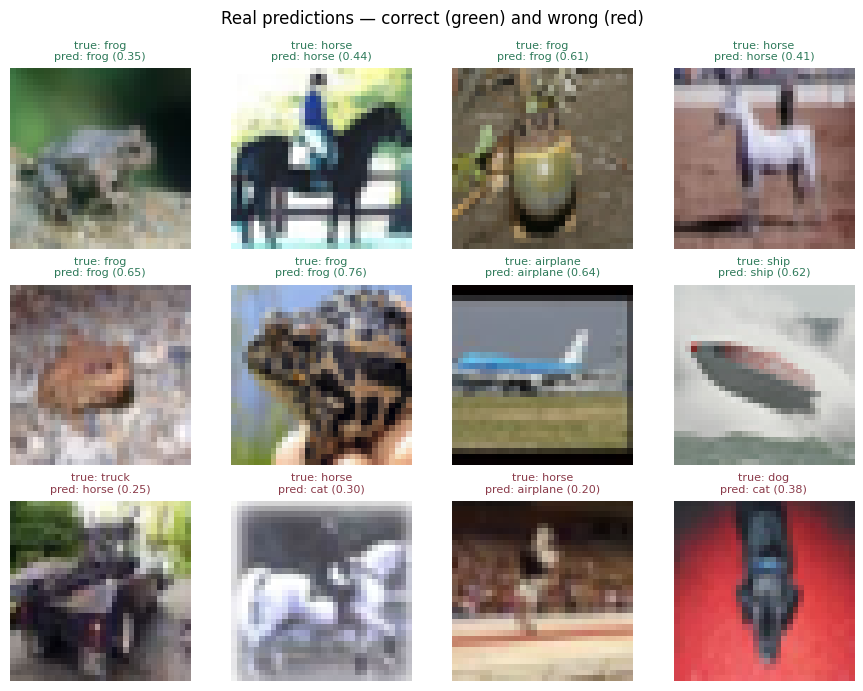

In [14]:
s = exp.samples
k = len(s.true_labels)
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for ax in axes.flat:
    ax.axis('off')
for i in range(k):
    ax = axes.flat[i]
    ax.imshow(s.images[i], cmap=None if s.images[i].ndim == 3 else 'gray')
    ok = s.true_labels[i] == s.pred_labels[i]
    ax.set_title(f'true: {s.classes[s.true_labels[i]]}\npred: {s.classes[s.pred_labels[i]]} ({s.confidences[i]:.2f})',
                 fontsize=8, color='#2E7A5A' if ok else '#8B3B4A')
plt.suptitle('Real predictions — correct (green) and wrong (red)')
plt.tight_layout()
plt.show()

## Recap

Image classification is a **workflow**, not a single model: real data → an input pipeline (resize + normalize + augment) → a **pretrained backbone** → a small **head** → softmax cross-entropy → honest evaluation. The dominant lesson is **transfer learning** — reusing ImageNet features beat training from scratch by a wide, measured margin at the same small budget, because low-level visual features are general. **Augmentation** regularizes (the overfitting gap roughly halved). And **accuracy hides failure**: the confusion matrix and per-class breakdown exposed the fine-grained animal confusions a single number concealed. Every quantity here was computed from a real run and cross-checked against `torch` / `scikit-learn`.

See the companion page for the transfer freeze-vs-fine-tune spectrum, augmentation theory, class imbalance, test-set discipline, pitfalls, and references — and the sibling chapters on the CNN mechanism (05 DL 13), transfer learning for vision (05), and data augmentation (06).